<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
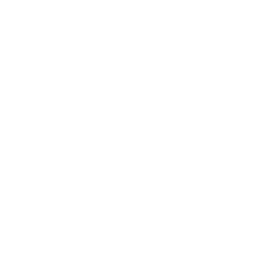
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Τεκμηρίωση Σχήματος Γονιδιωματικού Σχολιασμού Παραλλαγών</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Βιοπληροφορική / Διαχείριση Δεδομένων Κλινικής Γονιδιωματικής &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Σύνοψη για Στελέχη

Τεκμηριώστε το σχήμα των συνόλων δεδομένων σχολιασμού παραλλαγών τύπου VCF που χρησιμοποιούνται σε μια διοχέτευση κλινικής γονιδιωματικής. Χρησιμοποιήστε το PROC CONTENTS για να καταλογογραφήσετε όλα τα πεδία σχολιασμού — γονιδιωματικές συντεταγμένες, συχνότητες αλληλομόρφων, προβλεπόμενες λειτουργικές επιδράσεις, ταξινομήσεις ClinVar και μετρικές ποιότητας — διασφαλίζοντας ότι τα μεταγενέστερα εργαλεία ερμηνείας παραλλαγών ACMG λαμβάνουν σωστά τυποποιημένες και επισημασμένες εισόδους. Περίπου 5,000 εγγραφές παραλλαγών με 20+ στήλες σχολιασμού επιθεωρούνται για ακεραιότητα σχήματος πριν από την παράδοση στη διοχέτευση.

## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|--------|
| VARIANT_ANNOTATIONS | Σχολιασμένες παραλλαγές προερχόμενες από VCF | ~5,000 |
| GENE_PANEL | Ορισμοί στοχευμένου πάνελ γονιδίων | ~150 γονίδια |
| QUALITY_METRICS | Έλεγχος ποιότητας αλληλούχισης ανά δείγμα | ~50 δείγματα |

---

In [1]:
/* --------------------------------------------------------
   Δημιουργία συνόλου δεδομένων σχολιασμού παραλλαγών τύπου VCF
   5.000 παραλλαγές με πεδία κλινικού σχολιασμού
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ variant_annotations;
    CALL streaminit(42);
    LENGTH variant_id $20 chromosome $5 position 8
           ref_allele $10 alt_allele $10 gene_symbol $15
           transcript_id $20 consequence $30
           impact $10 hgvs_c $25 hgvs_p $25
           gnomad_af 8 clinvar_class $25 clinvar_id $12
           sift_score 8 sift_pred $15
           polyphen_score 8 polyphen_pred $15
           cadd_phred 8 revel_score 8
           genotype $5 allele_depth 8 read_depth 8
           qual_score 8 filter_status $10;
    ΕΤΙΚΕΤΑ variant_id='Ταυτότητα Παραλλαγής'
          chromosome='Χρωμόσωμα'
          position='Γονιδιωματική Θέση (GRCh38)'
          ref_allele='Αλληλόμορφο Αναφοράς'
          alt_allele='Εναλλακτικό Αλληλόμορφο'
          gene_symbol='Σύμβολο Γονιδίου HGNC'
          transcript_id='Ταυτότητα Μεταγραφήματος Ensembl'
          consequence='Επίπτωση Sequence Ontology'
          impact='Προβλεπόμενο Επίπεδο Επίπτωσης'
          hgvs_c='Σημειογραφία Κωδικοποίησης HGVS'
          hgvs_p='Σημειογραφία Πρωτεΐνης HGVS'
          gnomad_af='Συχνότητα Αλληλομόρφου gnomAD'
          clinvar_class='Ταξινόμηση ClinVar'
          clinvar_id='Κωδικός Καταχώρησης ClinVar'
          sift_score='Βαθμολογία SIFT'
          sift_pred='Πρόβλεψη SIFT'
          polyphen_score='Βαθμολογία PolyPhen-2'
          polyphen_pred='Πρόβλεψη PolyPhen-2'
          cadd_phred='Βαθμολογία CADD Phred'
          revel_score='Βαθμολογία Συνόλου REVEL'
          genotype='Γονότυπος Δείγματος'
          allele_depth='Βάθος Εναλλακτικού Αλληλομόρφου'
          read_depth='Συνολικό Βάθος Ανάγνωσης'
          qual_score='Βαθμολογία Ποιότητας Παραλλαγής'
          filter_status='Κατάσταση Φίλτρου';
    ARRAY genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    ARRAY conseqs[6] $30 _temporary_ ('missense_variant'
        'synonymous_variant' 'frameshift_variant'
        'stop_gained' 'splice_donor_variant' 'intron_variant');
    ARRAY impacts[6] $10 _temporary_ ('MODERATE' 'LOW' 'HIGH'
        'HIGH' 'HIGH' 'MODIFIER');
    ARRAY cv_classes[5] $25 _temporary_ ('Pathogenic'
        'Likely_pathogenic' 'Uncertain_significance'
        'Likely_benign' 'Benign');
    ARRAY refs[4] $1 _temporary_ ('A' 'C' 'G' 'T');
    ARRAY gts[3] $5 _temporary_ ('0/1' '1/1' '0/0');
    ΕΠΑΝΑΛΗΨΗ i = 1 ΕΩΣ 5000;
        variant_id = cat('VAR-', PUT(i, z8.));
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', PUT(chr_num, 2.));
        position = int(rand('uniform') * 200000000) + 10000;
        r_idx = int(rand('uniform') * 4) + 1;
        a_idx = mod(r_idx, 4) + 1;
        ref_allele = refs[r_idx];
        alt_allele = refs[a_idx];
        g_idx = int(rand('uniform') * 15) + 1;
        gene_symbol = genes[g_idx];
        transcript_id = cat('ENST00000', PUT(int(rand('uniform') * 99999) + 100000, z6.));
        c_idx = int(rand('uniform') * 6) + 1;
        consequence = conseqs[c_idx];
        impact = impacts[c_idx];
        codon_pos = int(rand('uniform') * 2000) + 1;
        hgvs_c = cat('c.', PUT(codon_pos, 4.), ref_allele, '>', alt_allele);
        ΕΑΝ c_idx <= 2 ΤΟΤΕ
            hgvs_p = cat('p.', PUT(int(rand('uniform') * 800) + 1, 4.));
        ΑΛΛΙΩΣ hgvs_p = 'p.?';
        gnomad_af = round(rand('beta', 0.5, 500), 0.000001);
        cv_idx = int(rand('uniform') * 5) + 1;
        clinvar_class = cv_classes[cv_idx];
        clinvar_id = cat('RCV', PUT(int(rand('uniform') * 900000) + 100000, z6.));
        sift_score = round(rand('uniform'), 0.001);
        ΕΑΝ sift_score < 0.05 ΤΟΤΕ sift_pred = 'DELETERIOUS';
        ΑΛΛΙΩΣ sift_pred = 'TOLERATED';
        polyphen_score = round(rand('uniform'), 0.001);
        ΕΑΝ polyphen_score > 0.908 ΤΟΤΕ polyphen_pred = 'PROB_DAMAGING';
        ΑΛΛΙΩΣ ΕΑΝ polyphen_score > 0.446 ΤΟΤΕ polyphen_pred = 'POSS_DAMAGING';
        ΑΛΛΙΩΣ polyphen_pred = 'BENIGN';
        cadd_phred = round(rand('uniform') * 40, 0.01);
        revel_score = round(rand('uniform'), 0.001);
        gt_idx = int(rand('uniform') * 3) + 1;
        genotype = gts[gt_idx];
        read_depth = int(rand('uniform') * 200) + 20;
        allele_depth = int(read_depth * (0.3 + rand('uniform') * 0.4));
        qual_score = round(rand('uniform') * 5000 + 100, 0.1);
        filter_status = ifc(qual_score > 500, 'PASS', 'LOW_QUAL');
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ i chr_num r_idx a_idx g_idx c_idx cv_idx gt_idx codon_pos;
ΕΚΤΕΛΕΣΗ;


NOTE: DATA variant_annotations

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote variant_annotations (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  3.14 seconds
  cpu   3.14 seconds


In [2]:
/* --------------------------------------------------------
   Δημιουργία ορισμών στοχευμένου πάνελ γονιδίων
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ gene_panel;
    CALL streaminit(42);
    LENGTH gene_symbol $15 gene_name $60 chromosome $5
           start_pos 8 end_pos 8 panel_name $30
           disease_association $50 inheritance $5;
    ΕΤΙΚΕΤΑ gene_symbol='Σύμβολο Γονιδίου HGNC'
          gene_name='Πλήρες Όνομα Γονιδίου'
          chromosome='Χρωμόσωμα'
          start_pos='Θέση Έναρξης Γονιδίου'
          end_pos='Θέση Λήξης Γονιδίου'
          panel_name='Κλινικό Πάνελ Γονιδίων'
          disease_association='Σχετιζόμενη Νόσος'
          inheritance='Πρότυπο Κληρονομικότητας';
    ARRAY genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    ARRAY gnames[15] $60 _temporary_ (
        'BRCA1 DNA Repair Associated'
        'BRCA2 DNA Repair Associated'
        'Tumor Protein P53'
        'Epidermal Growth Factor Receptor'
        'KRAS Proto-Oncogene'
        'PI3-Kinase Catalytic Subunit Alpha'
        'Phosphatase and Tensin Homolog'
        'APC Regulator of WNT Signaling'
        'MutL Homolog 1'
        'MutS Homolog 2'
        'ATM Serine/Threonine Kinase'
        'Checkpoint Kinase 2'
        'Partner and Localizer of BRCA2'
        'RAD51 Paralog C'
        'RAD51 Paralog D');
    ARRAY diseases[15] $50 _temporary_ (
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Li-Fraumeni Syndrome'
        'Non-Small Cell Lung Cancer'
        'Colorectal Cancer'
        'Breast Cancer'
        'Cowden Syndrome'
        'Familial Adenomatous Polyposis'
        'Lynch Syndrome'
        'Lynch Syndrome'
        'Ataxia-Telangiectasia'
        'Li-Fraumeni Syndrome'
        'Hereditary Breast Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer');
    ARRAY inhrt[15] $5 _temporary_ ('AD' 'AD' 'AD' 'AD' 'AD'
        'AD' 'AD' 'AD' 'AD' 'AD' 'AR' 'AD' 'AD' 'AD' 'AD');
    ΕΠΑΝΑΛΗΨΗ g = 1 ΕΩΣ 15;
        gene_symbol = genes[g];
        gene_name = gnames[g];
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', PUT(chr_num, 2.));
        start_pos = int(rand('uniform') * 150000000) + 1000000;
        end_pos = start_pos + int(rand('uniform') * 100000) + 5000;
        panel_name = 'HEREDITARY_CANCER_V3';
        disease_association = diseases[g];
        inheritance = inhrt[g];
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ g chr_num;
ΕΚΤΕΛΕΣΗ;


NOTE: DATA gene_panel


NOTE: Wrote gene_panel (15 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [3]:
/* --------------------------------------------------------
   Δημιουργία μετρικών ποιότητας αλληλούχισης ανά δείγμα
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ quality_metrics;
    CALL streaminit(42);
    LENGTH sample_id $15 run_id $12 platform $15
           mean_coverage 8 pct_target_20x 8 pct_target_100x 8
           total_variants 8 ti_tv_ratio 8 het_hom_ratio 8
           contamination_est 8 qc_status $10;
    ΕΤΙΚΕΤΑ sample_id='Ταυτότητα Δείγματος'
          run_id='Ταυτότητα Εκτέλεσης Αλληλούχισης'
          platform='Πλατφόρμα Αλληλούχισης'
          mean_coverage='Μέση Κάλυψη Στόχου'
          pct_target_20x='Ποσοστό Βάσεων >= 20x'
          pct_target_100x='Ποσοστό Βάσεων >= 100x'
          total_variants='Σύνολο Κληθεισών Παραλλαγών'
          ti_tv_ratio='Λόγος Μετάπτωσης/Μεταστροφής'
          het_hom_ratio='Λόγος Ετερο/Ομοζυγωτίας'
          contamination_est='Εκτιμώμενη Επιμόλυνση'
          qc_status='Κατάσταση Επιτυχίας/Αποτυχίας QC';
    ΕΠΑΝΑΛΗΨΗ s = 1 ΕΩΣ 50;
        sample_id = cat('SAMP-', PUT(s, z6.));
        run_id = cat('RUN-', PUT(int((s - 1) / 10) + 1, z4.));
        platform = 'ILLUMINA_NOVA';
        mean_coverage = round(250 + rand('normal') * 50, 0.1);
        pct_target_20x = round(MIN(99.5, 95 + rand('uniform') * 4.5), 0.01);
        pct_target_100x = round(MIN(98, 85 + rand('uniform') * 13), 0.01);
        total_variants = int(rand('uniform') * 2000) + 3000;
        ti_tv_ratio = round(2.0 + rand('normal') * 0.15, 0.01);
        het_hom_ratio = round(1.5 + rand('normal') * 0.2, 0.01);
        contamination_est = round(MAX(0, rand('uniform') * 0.02), 0.0001);
        ΕΑΝ mean_coverage < 150 OR pct_target_20x < 95
            OR contamination_est > 0.015 ΤΟΤΕ qc_status = 'FAIL';
        ΑΛΛΙΩΣ qc_status = 'PASS';
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ s;
ΕΚΤΕΛΕΣΗ;


NOTE: DATA quality_metrics


NOTE: Wrote quality_metrics (50 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                       Επίπτωση Παραλλαγής ανά Ταξινόμηση ClinVar                                       

                                                   The FREQ Procedure

Table of Προβλεπόμενο Επίπεδο Επίπτωσης by Ταξινόμηση ClinVar

Προβλεπόμενο Επίπεδο Επίπτωσης                             |                Benign |         Likely_benign |     Likely_pathogenic |            Pathogenic |Uncertain_significance |                  Total
-----------------------------------------------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------
HIGH                                                       |                     9 |                    10 |                    19 |                    12 |                    12 |                     62
                                                           |                  9.00 |                 10.00 |                 19.00 |


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_impact_clinvar_class.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


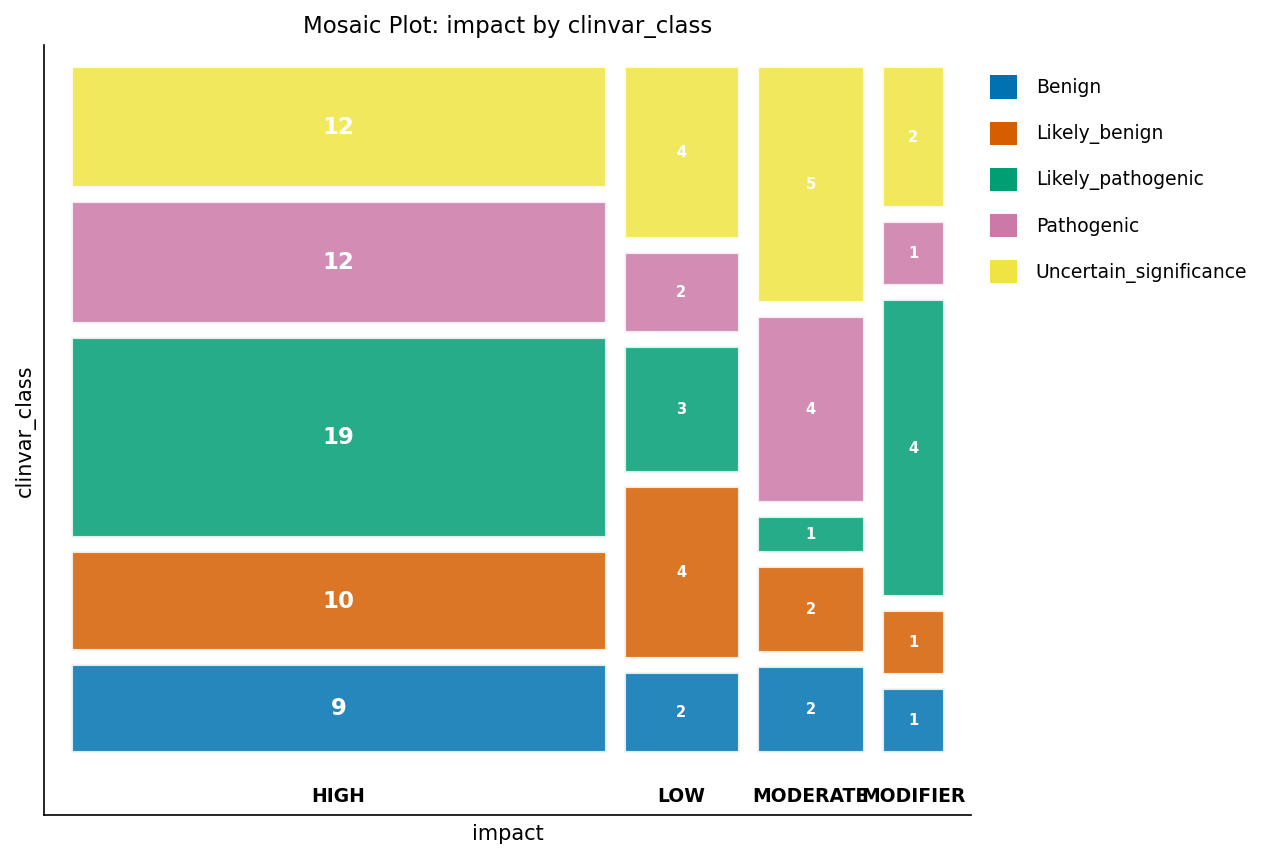

In [4]:
/* --------------------------------------------------------
   Βασική σύνοψη σχολιασμού παραλλαγών
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=variant_annotations;
    TABLES impact * clinvar_class / nocum;
    LABEL impact='Προβλεπόμενο Επίπεδο Επίπτωσης'
          clinvar_class='Ταξινόμηση ClinVar';
    TITLE 'Επίπτωση Παραλλαγής ανά Ταξινόμηση ClinVar';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=quality_metrics n mean MIN MAX;
    ΜΕΤΑΒΛΗΤΗ mean_coverage ti_tv_ratio contamination_est;
    LABEL mean_coverage='Μέση Κάλυψη Στόχου'
          ti_tv_ratio='Λόγος Μετάπτωσης/Μεταστροφής'
          contamination_est='Εκτιμώμενη Επιμόλυνση';
    TITLE 'Σύνοψη Μετρικών Ποιότητας Αλληλούχισης';
ΕΚΤΕΛΕΣΗ;

---

                                         Σύνοψη Μετρικών Ποιότητας Αλληλούχισης                                         

                                         Σύνοψη Μετρικών Ποιότητας Αλληλούχισης                                         




NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=schema_lengths created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: DATA schema_lengths


NOTE: Read 25 rows from schema_lengths.
NOTE: Wrote schema_lengths (25 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=schema_lengths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


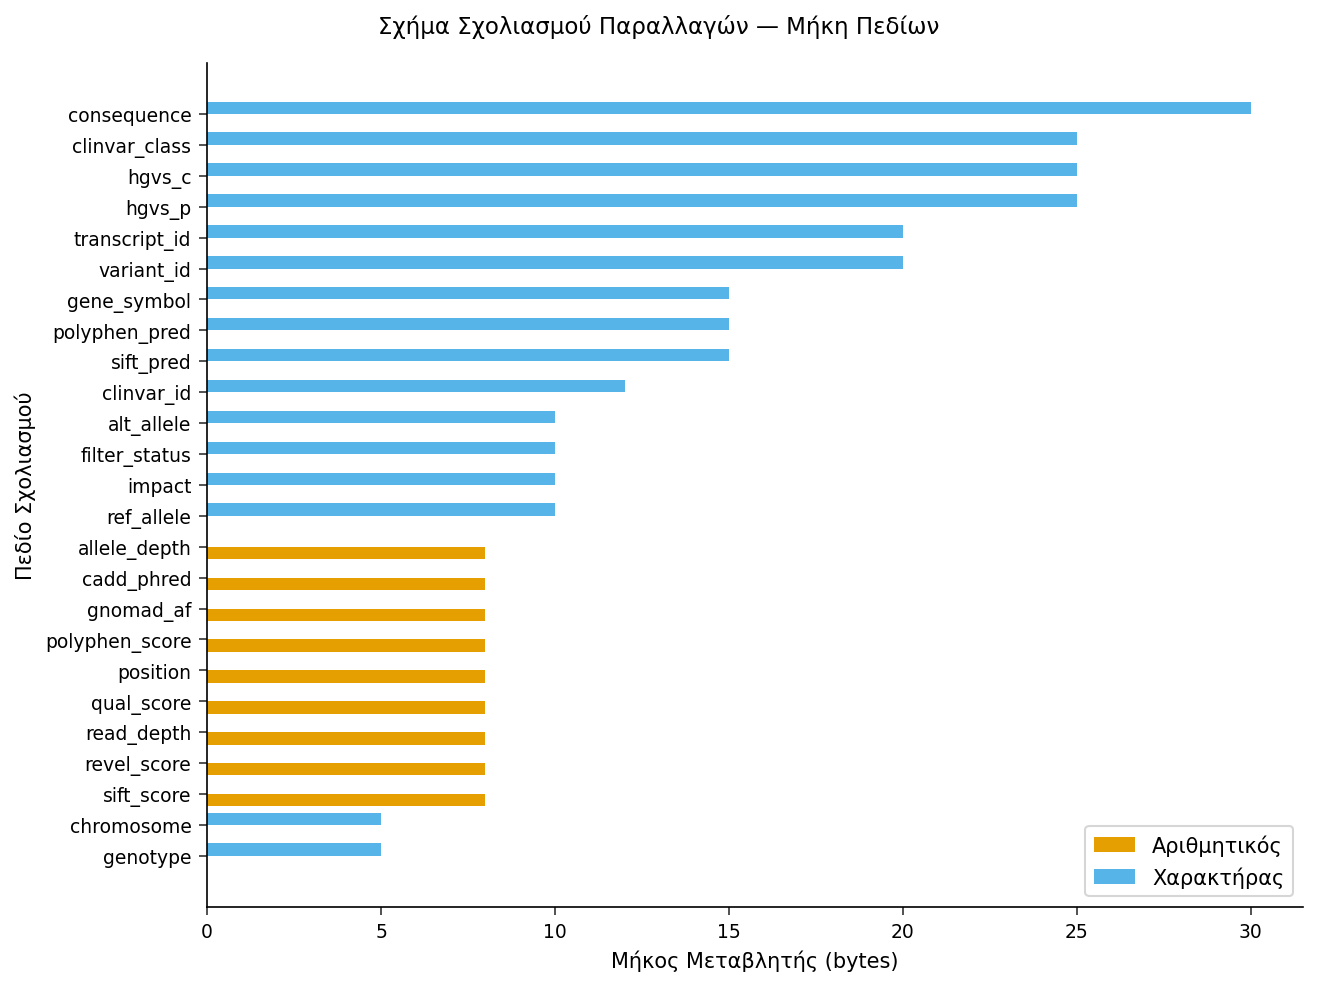

In [5]:
/* --------------------------------------------------------
   Κατανομή τύπου και μήκους μεταβλητών.
   Καταγράφουμε τα μεταδεδομένα του σχήματος σχολιασμού με
   PROC CONTENTS OUT=, μετά σχεδιάζουμε τα μήκη πεδίων ανά
   τύπο. Οι κωδικοί TYPE αντιστοιχούν 1 -> Αριθμητικός,
   2 -> Χαρακτήρας για το υπόμνημα.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΠΕΡΙΕΧΟΜΕΝΑ ΔΕΔΟΜΕΝΑ=variant_annotations out=schema_lengths NOPRINT;
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ schema_lengths;
    ΟΡΙΣΜΟΣ schema_lengths;
    LENGTH type_label $30;
    ΕΑΝ TYPE = 1 ΤΟΤΕ type_label = 'Αριθμητικός';
    ΑΛΛΙΩΣ type_label = 'Χαρακτήρας';
    LABEL type_label='Τύπος Μεταβλητής';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=schema_lengths;
    HBAR NAME / RESPONSE=LENGTH GROUP=type_label
        CATEGORYORDER=respdesc;
    XAXIS ΕΤΙΚΕΤΑ='Μήκος Μεταβλητής (bytes)';
    YAXIS ΕΤΙΚΕΤΑ='Πεδίο Σχολιασμού';
    TITLE 'Σχήμα Σχολιασμού Παραλλαγών — Μήκη Πεδίων';
ΕΚΤΕΛΕΣΗ;

---

In [6]:
/* --------------------------------------------------------
   PROC CONTENTS: Τεκμηρίωση του πλήρους σχήματος σχολιασμού
   παραλλαγών — τύποι, μήκη, ετικέτες για όλα τα 25 πεδία.
   Καταγράφουμε τα μεταδεδομένα μεταβλητών με OUT= ώστε τα
   μεταγενέστερα βήματα να επικυρώνουν το σχήμα προγραμματιστικά.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΠΕΡΙΕΧΟΜΕΝΑ ΔΕΔΟΜΕΝΑ=variant_annotations out=variant_schema NOPRINT;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=variant_schema;
    ΜΕΤΑΒΛΗΤΗ NAME TYPE LENGTH VARNUM LABEL;
    TITLE 'Σύνολο Δεδομένων Σχολιασμού Παραλλαγών — Πλήρες Σχήμα';
ΕΚΤΕΛΕΣΗ;

                                         Σύνοψη Μετρικών Ποιότητας Αλληλούχισης                                         

                                 Σύνολο Δεδομένων Σχολιασμού Παραλλαγών — Πλήρες Σχήμα                                  

  Obs            NAME  TYPE  LENGTH  VARNUM                                                         LABEL
    1  allele_depth       1       8      22  Βάθος Εναλλακτικού Αλληλομόρφου
    2  alt_allele         2      10       5  Εναλλακτικό Αλληλόμορφο
    3  cadd_phred         1       8      19  Βαθμολογία CADD Phred
    4  chromosome         2       5       2  Χρωμόσωμα
    5  clinvar_class      2      25      13  Ταξινόμηση ClinVar
    6  clinvar_id         2      12      14  Κωδικός Καταχώρησης ClinVar
    7  consequence        2      30       8  Επίπτωση Sequence Ontology
    8  filter_status      2      10      25  Κατάσταση Φίλτρου
    9  gene_symbol        2      15       6  Σύμβολο Γονιδίου HGNC
   10  genotype           2       5      21


NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=variant_schema created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: PROC PRINT data=variant_schema

NOTE: PROC PRINT completed: 25 observations printed, 5 variables


In [7]:
/* --------------------------------------------------------
   PROC CONTENTS: Τεκμηρίωση σχήματος πάνελ γονιδίων
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΠΕΡΙΕΧΟΜΕΝΑ ΔΕΔΟΜΕΝΑ=gene_panel out=panel_schema NOPRINT;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=panel_schema;
    ΜΕΤΑΒΛΗΤΗ NAME TYPE LENGTH VARNUM LABEL;
    TITLE 'Ορισμός Πάνελ Γονιδίων — Σχήμα';
ΕΚΤΕΛΕΣΗ;

                                 Σύνολο Δεδομένων Σχολιασμού Παραλλαγών — Πλήρες Σχήμα                                  

                                             Ορισμός Πάνελ Γονιδίων — Σχήμα                                             

  Obs                 NAME  TYPE  LENGTH  VARNUM                                            LABEL
    1  chromosome              2       5       3  Χρωμόσωμα
    2  disease_association     2      50       7  Σχετιζόμενη Νόσος
    3  end_pos                 1       8       5  Θέση Λήξης Γονιδίου
    4  gene_name               2      60       2  Πλήρες Όνομα Γονιδίου
    5  gene_symbol             2      15       1  Σύμβολο Γονιδίου HGNC
    6  inheritance             2       5       8  Πρότυπο Κληρονομικότητας
    7  panel_name              2      30       6  Κλινικό Πάνελ Γονιδίων
    8  start_pos               1       8       4  Θέση Έναρξης Γονιδίου




NOTE: PROC CONTENTS data=gene_panel

NOTE: PROC CONTENTS: OUT=panel_schema created with 8 variables
NOTE: PROC CONTENTS: data=gene_panel obs=15 vars=8 (NOPRINT)
NOTE: PROC PRINT data=panel_schema

NOTE: PROC PRINT completed: 8 observations printed, 5 variables


In [8]:
/* --------------------------------------------------------
   PROC CONTENTS: Τεκμηρίωση σχήματος μετρικών QC
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΠΕΡΙΕΧΟΜΕΝΑ ΔΕΔΟΜΕΝΑ=quality_metrics out=qc_schema NOPRINT;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=qc_schema;
    ΜΕΤΑΒΛΗΤΗ NAME TYPE LENGTH VARNUM LABEL;
    TITLE 'Μετρικές Ποιότητας Αλληλούχισης — Σχήμα';
ΕΚΤΕΛΕΣΗ;

                                             Ορισμός Πάνελ Γονιδίων — Σχήμα                                             

                                        Μετρικές Ποιότητας Αλληλούχισης — Σχήμα                                         

  Obs               NAME  TYPE  LENGTH  VARNUM                                                           LABEL
    1  contamination_est     1       8      10  Εκτιμώμενη Επιμόλυνση
    2  het_hom_ratio         1       8       9  Λόγος Ετερο/Ομοζυγωτίας
    3  mean_coverage         1       8       4  Μέση Κάλυψη Στόχου
    4  pct_target_100x       1       8       6  Ποσοστό Βάσεων >= 100x
    5  pct_target_20x        1       8       5  Ποσοστό Βάσεων >= 20x
    6  platform              2      15       3  Πλατφόρμα Αλληλούχισης
    7  qc_status             2      10      11  Κατάσταση Επιτυχίας/Αποτυχίας QC
    8  run_id                2      12       2  Ταυτότητα Εκτέλεσης Αλληλούχισης
    9  sample_id             2      15       1  Ταυτότητα Δείγ


NOTE: PROC CONTENTS data=quality_metrics

NOTE: PROC CONTENTS: OUT=qc_schema created with 11 variables
NOTE: PROC CONTENTS: data=quality_metrics obs=50 vars=11 (NOPRINT)
NOTE: PROC PRINT data=qc_schema

NOTE: PROC PRINT completed: 11 observations printed, 5 variables


In [9]:
/* --------------------------------------------------------
   Επικύρωση σχήματος: έλεγχος ότι τα πεδία σχολιασμού
   ικανοποιούν τις απαιτήσεις της διοχέτευσης για ερμηνεία
   ACMG. Διαβάζει τα μεταδεδομένα PROC CONTENTS OUT=, όπου
   TYPE=1 σημαίνει αριθμητικός και TYPE=2 σημαίνει χαρακτήρας.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ schema_validation;
    ΟΡΙΣΜΟΣ variant_schema;
    LENGTH requirement $150 status $30;
    /* Τα αριθμητικά πεδία βαθμολογίας πρέπει να αποθηκεύονται ως αριθμητικά (TYPE=1) */
    ΕΑΝ NAME IN ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        AND TYPE ne 1 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
        requirement = 'Πρέπει να είναι αριθμητικό για κατώφλια βαθμολογίας';
        status = 'ΑΠΟΤΥΧΙΑ';
    ΤΕΛΟΣ;
    ΑΛΛΙΩΣ ΕΑΝ NAME IN ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        AND TYPE = 1 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
        requirement = 'Επιβεβαιωμένος αριθμητικός τύπος';
        status = 'ΕΠΙΤΥΧΙΑ';
    ΤΕΛΟΣ;
    /* Η κλάση ClinVar χρειάζεται επαρκές μήκος χαρακτήρων */
    ΑΛΛΙΩΣ ΕΑΝ NAME = 'clinvar_class' AND LENGTH < 25 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
        requirement = 'Ελάχ. $25 για πλήρες κείμενο ταξινόμησης';
        status = 'ΑΠΟΤΥΧΙΑ';
    ΤΕΛΟΣ;
    ΑΛΛΙΩΣ ΕΑΝ NAME = 'clinvar_class' ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
        requirement = 'Επαρκές μήκος χαρακτήρων';
        status = 'ΕΠΙΤΥΧΙΑ';
    ΤΕΛΟΣ;
    /* Όλα τα πεδία πρέπει να φέρουν ετικέτα για το λεξικό δεδομένων */
    ΑΛΛΙΩΣ ΕΑΝ LABEL = '' ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
        requirement = 'Απαιτείται ετικέτα για το λεξικό δεδομένων';
        status = 'ΑΠΟΤΥΧΙΑ';
    ΤΕΛΟΣ;
    ΑΛΛΙΩΣ ΕΠΑΝΑΛΗΨΗ;
        requirement = 'Γενική επικύρωση';
        status = 'ΕΠΙΤΥΧΙΑ';
    ΤΕΛΟΣ;
    LABEL requirement='Απαίτηση' status='Κατάσταση';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=schema_validation;
    ΜΕΤΑΒΛΗΤΗ NAME TYPE LENGTH LABEL requirement status;
    TITLE 'Αναφορά Επικύρωσης Σχήματος Διοχέτευσης ACMG';
ΕΚΤΕΛΕΣΗ;

                                      Αναφορά Επικύρωσης Σχήματος Διοχέτευσης ACMG                                      

  Obs            NAME  TYPE  LENGTH                                                         LABEL                                                     requirement            status
    1  allele_depth       1       8  Βάθος Εναλλακτικού Αλληλομόρφου                               Επιβεβαιωμένος αριθμητικός τύπος                                ΕΠΙΤΥΧΙΑ
    2  alt_allele         2      10  Εναλλακτικό Αλληλόμορφο                                       Γενική επικύρωση                                                ΕΠΙΤΥΧΙΑ
    3  cadd_phred         1       8  Βαθμολογία CADD Phred                                         Επιβεβαιωμένος αριθμητικός τύπος                                ΕΠΙΤΥΧΙΑ
    4  chromosome         2       5  Χρωμόσωμα                                                     Γενική επικύρωση                                                ΕΠΙΤΥΧΙΑ
    5  cli


NOTE: DATA schema_validation


NOTE: Read 25 rows from variant_schema.
NOTE: Wrote schema_validation (25 rows, 18 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=schema_validation

NOTE: PROC PRINT completed: 25 observations printed, 6 variables


---

### Ερμηνεία

Το σχήμα σχολιασμού παραλλαγών περιέχει 25 πεδία που καλύπτουν γονιδιωματικές συντεταγμένες, λειτουργικές προβλέψεις, πληθυσμιακές συχνότητες και δείκτες ποιότητας ανά δείγμα. Και τα εννέα αριθμητικά πεδία βαθμολογίας (συχνότητα αλληλομόρφου gnomAD, SIFT, PolyPhen-2, CADD, REVEL, βαθμολογία ποιότητας, βάθος αλληλομόρφου, βάθος ανάγνωσης και γονιδιωματική θέση) είναι σωστά τυποποιημένα ως αριθμητικά, επιτρέποντας στη μηχανή ερμηνείας ACMG να εφαρμόσει φιλτράρισμα βασισμένο σε κατώφλια χωρίς μετατροπή τύπου. Το πεδίο clinvar_class στα $25 χωρά τη μεγαλύτερη συμβολοσειρά ταξινόμησης ClinVar (Uncertain_significance με 24 χαρακτήρες). Κάθε πεδίο σχολιασμού φέρει μια περιγραφική ετικέτα, ικανοποιώντας την απαίτηση λεξικού δεδομένων του κλινικού εργαστηρίου υπό τις απαιτήσεις διαπίστευσης CAP. Το σχήμα του πάνελ γονιδίων χαρτογραφεί 15 γονίδια προδιάθεσης καρκίνου με πρότυπα κληρονομικότητας και συσχετίσεις νόσων, παρέχοντας το πλαίσιο αναφοράς για τον σχολιασμό παραλλαγής-προς-γονίδιο. Το σύνολο δεδομένων μετρικών QC αλληλούχισης τεκμηριώνει 50 δείγματα σε 5 εκτελέσεις, με εκτιμήσεις επιμόλυνσης και κατώφλια κάλυψης που ελέγχουν την αξιοπιστία της κλήσης παραλλαγών. Αυτό το πακέτο τεκμηρίωσης σχήματος υποστηρίζει τον φάκελο επικύρωσης του εργαστηρίου για την υποβολή στο New York State CLEP.

---

In [10]:
/* --------------------------------------------------------
   Εξαγωγή της τεκμηρίωσης σχήματος παραλλαγών και της
   αναφοράς επικύρωσης για τη διαπίστευση του εργαστηρίου
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=variant_schema
    OUTFILE='variant_annotation_schema.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=schema_validation
    OUTFILE='acmg_schema_validation.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;


NOTE: PROC EXPORT data=variant_schema outfile=variant_annotation_schema.csv

NOTE: Exported 25 rows to variant_annotation_schema.csv.
NOTE: PROC EXPORT data=schema_validation outfile=acmg_schema_validation.csv

NOTE: Exported 25 rows to acmg_schema_validation.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη του <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>